## 1 - Model 3 Neural Network
While tree-based ensemble models such as Random Forest are widely regarded as strong baselines for intrusion detection on NSL-KDD, neural networks remain an important complementary modeling family. The consulted studies show that Multi-Layer Perceptrons (MLPs) and related neural architectures are capable of capturing complex non-linear relationships between network traffic features and attack patterns, particularly when interactions between attributes are subtle or highly overlapping. However, the literature also emphasizes that neural networks do not automatically outperform classical machine-learning methods on NSL-KDD. Their performance is highly sensitive to preprocessing choices, feature scaling, class imbalance, architecture design, and regularization.

Main objectives of this model are to:
* Assess whether a non-linear, fully connected neural network can improve multi-class detection performance compared to linear models and tree-based ensembles
* Evaluate the sensitivity of neural networks to feature scaling, class imbalance, and label distribution in NSL-KDD
* Compare predictive performance using standard metrics (accuracy, macro-F1, per-class recall) under the same data splits used for previous models
* Analyze training dynamics (loss curves, convergence behavior) to identify overfitting or underfitting tendencies
* Position neural networks fairly within the overall modeling pipeline, without assuming superiority over simpler or more interpretable methods


## 1 - Packages

In [1]:
# Start by importing all required libs...
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, roc_curve, auc, f1_score, accuracy_score, precision_score, recall_score, average_precision_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from utils import load_split, make_binary_labels
import joblib

%matplotlib inline
plt.style.use('./deeplearning.mplstyle')
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)
np.set_printoptions(precision=2)

print("All packages loaded successfully.")

2025-12-28 23:13:04.993455: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-28 23:13:05.032013: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-28 23:13:06.025593: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


All packages loaded successfully.


## 2 - Loading data

In [2]:
DATA_DIR   = Path("data/processed")

X_train, y_train = load_split("train", DATA_DIR)
X_val,   y_val   = load_split("val", DATA_DIR)
X_test,  y_test  = load_split("test", DATA_DIR)

print ('The shape of X is: ' + str(X_train.shape))
print ('The shape of y is: ' + str(y_train.shape))

The shape of X is: (100778, 122)
The shape of y is: (100778,)


## 3 - Normalising data and converting multiclass to binary

In [ ]:
# Reuse encoder form data preparation pipeline
y_encoder = joblib.load("data/processed/label_encoder.joblib")
classes = y_encoder.classes_
normal_id = np.where(classes == "normal")[0][0]
print("Normal class: ", normal_id)

y_train_bin = make_binary_labels(y_train, normal_id)
y_val_bin   = make_binary_labels(y_val,   normal_id)
y_test_bin  = make_binary_labels(y_test,  normal_id)

print(pd.Series(y_train_bin).value_counts())

# some nn params
input_shape = (X_train.shape[1],) 
num_classes = len(y_encoder.classes_)

Normal class:  1
0    53874
1    46904
Name: count, dtype: int64


## 4 - Multi-classification

### 4.1 – Model 3MCv1: Multiclass neural network

This model applies a feed-forward neural network to the multi-class NSL-KDD intrusion detection task. The network consists of two fully connected hidden layers with ReLU activations. The model uses a softmax output layer and are trained with sparse categorical cross-entropy using integer-encoded class labels. Dropout regularisation is applied after each hidden layer to mitigate overfitting by randomly deactivating a fraction of neurons during training, encouraging more robust feature representations and improved generalisation.

In [ ]:
print("Building model 3MCv1")
model_3MCv1 = Sequential([
    Dense(128, activation='relu', input_shape=input_shape),
    Dropout(0.3), 
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_3MCv1.compile(optimizer='adam', 
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

# Train
print("Training  model 3MCv1...")
history_3MCv1 = model_3MCv1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Building model 3MCv1


/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1766959999.571663   34534 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Training  model 3MCv1...
Epoch 1/50


2025-12-28 23:13:21.015531: I external/local_xla/xla/service/service.cc:163] XLA service 0x7cbdf40157c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-28 23:13:21.015546: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-12-28 23:13:21.042641: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-28 23:13:21.173797: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-12-28 23:13:21.267035: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-28 23:13:21.

  90/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7641 - loss: 0.8164

...

1559/1575 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9461 - loss: 0.1940

2025-12-28 23:13:26.262782: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-28 23:13:26.262805: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-28 23:13:26.262833: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-28 23:13:26.262842: I external/l

1575/1575 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9464 - loss: 0.1929

2025-12-28 23:13:29.294801: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-28 23:13:29.758846: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_35', 116 bytes spill stores, 116 bytes spill loads

2025-12-28 23:13:30.639123: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-28 23:13:30.639147: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were fi

1575/1575 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9750 - loss: 0.0887 - val_accuracy: 0.9911 - val_loss: 0.0280
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9898 - loss: 0.0343 - val_accuracy: 0.9924 - val_loss: 0.0231
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9917 - loss: 0.0273 - val_accuracy: 0.9924 - val_loss: 0.0229
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9924 - loss: 0.0238 - val_accuracy: 0.9940 - val_loss: 0.0206
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9932 - loss: 0.0217 - val_accuracy: 0.9934 - val_loss: 0.0188
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9933 - loss: 0.0208 - val_accuracy: 0.9947 - val_loss: 0.0181
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9938 - loss: 0.0200 - val_accuracy: 0.9947 - val_loss: 0.0178
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9939 - loss: 0.0185 - val_accura

In [5]:
# Prediction and accuracy Model 3MCv1
test_loss_3MCv1, test_acc_3MCv1 = model_3MCv1.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc_3MCv1*100:.2f}%")

y_pred_3MCv1_probs = model_3MCv1.predict(X_test)

y_pred_3MCv1 = np.argmax(y_pred_3MCv1_probs, axis=1)

print("Classification report 3MCv1")

report = classification_report(y_test, y_pred_3MCv1, output_dict=True)
print(classification_report(y_test, y_pred_3MCv1))  

2025-12-28 23:15:54.829589: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-28 23:15:54.829610: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-28 23:15:55.265510: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_28', 8 bytes spill stores, 8 bytes spill loads

2025-12-28 23:15:55.419879: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Reg

705/705 - 3s - 4ms/step - accuracy: 0.7805 - loss: 6.2340

Test Accuracy: 78.05%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification report 3MCv1
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      7458
           1       0.69      0.97      0.80      9711
           2       0.83      0.67      0.74      2423
           3       0.93      0.03      0.06      2885
           4       0.76      0.37      0.50        67

    accuracy                           0.78     22544
   macro avg       0.83      0.58      0.60     22544
weighted avg       0.82      0.78      0.73     22544



### 4.2 - Model 3MCv2: Neural network with L1 regularisation and early stopping mechanism

In model 3mcv2 L1 regularisation is applied to the dense layers by adding an L1 penalty to the loss function during training. This penalty is proportional to the absolute magnitude of the network weights and encourages sparsity by driving less informative weights toward zero. In the context of intrusion detection, where many input features may be redundant or weakly informative, L1 regularisation should help reduce model complexity and therefore limits overfitting. Early stopping is applied to prevent unnecessary training once validation loss stops improving, improving generalisation.


In [16]:
print("Building model 3mcv2 l1 regularised")

reg = tf.keras.regularizers.l1(1e-4)

model_3MCv2 = Sequential([
    Dense(128, activation="relu", input_shape=input_shape, kernel_regularizer=reg),
    Dropout(0.3),
    Dense(64, activation="relu", kernel_regularizer=reg),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model_3MCv2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True
)

print("Starting training")

history_3MCv2 = model_3MCv2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)


Building model 3mcv2 l1 regularised
Starting training
Epoch 1/50


/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9736 - loss: 0.1910 - val_accuracy: 0.9895 - val_loss: 0.1098
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9877 - loss: 0.1002 - val_accuracy: 0.9917 - val_loss: 0.0829
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9893 - loss: 0.0826 - val_accuracy: 0.9915 - val_loss: 0.0677
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9897 - loss: 0.0736 - val_accuracy: 0.9928 - val_loss: 0.0618
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9904 - loss: 0.0668 - val_accuracy: 0.9908 - val_loss: 0.0605
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9908 - loss: 0.0632 - val_accuracy: 0.9929 - val_loss: 0.0547
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9906 - loss: 0.0611 - val_accuracy: 0.9926 - val_loss: 0.0532
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9908 - loss: 0.0590 - val_accurac

In [7]:
# Prediction and accuracy Model 3MCv2
test_loss_3MCv2, test_acc_3MCv2 = model_3MCv2.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc_3MCv2*100:.2f}%")

y_pred_3MCv2_probs = model_3MCv2.predict(X_test)

y_pred_3MCv2 = np.argmax(y_pred_3MCv2_probs, axis=1)

print("Classification Report 3MCv2")
report = classification_report(y_test, y_pred_3MCv2, output_dict=True)
print(classification_report(y_test, y_pred_3MCv2))

705/705 - 2s - 2ms/step - accuracy: 0.7403 - loss: 1.8779

Test Accuracy: 74.03%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification Report 3MCv2
              precision    recall  f1-score   support

           0       0.91      0.78      0.84      7458
           1       0.65      0.93      0.76      9711
           2       0.83      0.70      0.76      2423
           3       0.89      0.04      0.08      2885
           4       0.90      0.13      0.23        67

    accuracy                           0.74     22544
   macro avg       0.84      0.52      0.54     22544
weighted avg       0.79      0.74      0.70     22544



### 4.3 - Model 3MCv3: Neural network with class weighting

To address the severe class imbalance observed in the NSL-KDD dataset, Model 3MCv3 incorporates class weighting during training. Class weights are computed from the training labels using the balanced weighting scheme, which assigns higher weights to underrepresented classes and lower weights to majority classes based on their relative frequencies. These weights are passed to the training procedure and directly modify the loss function by scaling the contribution of each sample according to its class.

In [8]:
print("Building model 3mcv3 class weighted")

model_3MCv3 = Sequential([
    Dense(128, activation="relu", input_shape=input_shape),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model_3MCv3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True
)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

print("Starting training")

history_3MCv3 = model_3MCv3.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    class_weight=class_weight,
    verbose=1
)


Building model 3mcv3 class weighted
Starting training
Epoch 1/50


/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9135 - loss: 0.8767 - val_accuracy: 0.9353 - val_loss: 0.1825
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9357 - loss: 0.3695 - val_accuracy: 0.9248 - val_loss: 0.1879
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9383 - loss: 0.2908 - val_accuracy: 0.9451 - val_loss: 0.1443
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9466 - loss: 0.2241 - val_accuracy: 0.9666 - val_loss: 0.1099
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9529 - loss: 0.1750 - val_accuracy: 0.9666 - val_loss: 0.1058
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9587 - loss: 0.3115 - val_accuracy: 0.9715 - val_loss: 0.0871
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9617 - loss: 0.1999 - val_accuracy: 0.9720 - val_loss: 0.0808
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9613 - loss: 0.3389 - val_accurac

In [9]:
# Prediction and accuracy Model 3MCv3
test_loss_3MCv3, test_acc_3MCv3 = model_3MCv3.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc_3MCv3*100:.2f}%")

y_pred_3MCv3_probs = model_3MCv3.predict(X_test)

y_pred_3MCv3 = np.argmax(y_pred_3MCv3_probs, axis=1)

print("Classification report 3MCv3")
report = classification_report(y_test, y_pred_3MCv3, output_dict=True)
print(classification_report(y_test, y_pred_3MCv3))

705/705 - 1s - 2ms/step - accuracy: 0.7921 - loss: 1.7132

Test Accuracy: 79.21%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification report 3MCv3
              precision    recall  f1-score   support

           0       0.97      0.85      0.90      7458
           1       0.72      0.96      0.82      9711
           2       0.80      0.75      0.78      2423
           3       0.88      0.13      0.23      2885
           4       0.10      0.70      0.17        67

    accuracy                           0.79     22544
   macro avg       0.70      0.68      0.58     22544
weighted avg       0.83      0.79      0.77     22544



### 4.4 - Accuracy and loss comparison of both multi-classclassification models over epochs

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 710us/step
705/705 - 1s - 1ms/step - accuracy: 0.7805 - loss: 6.2340
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step
705/705 - 1s - 923us/step - accuracy: 0.7403 - loss: 1.8779
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step
705/705 - 1s - 812us/step - accuracy: 0.7921 - loss: 1.7132


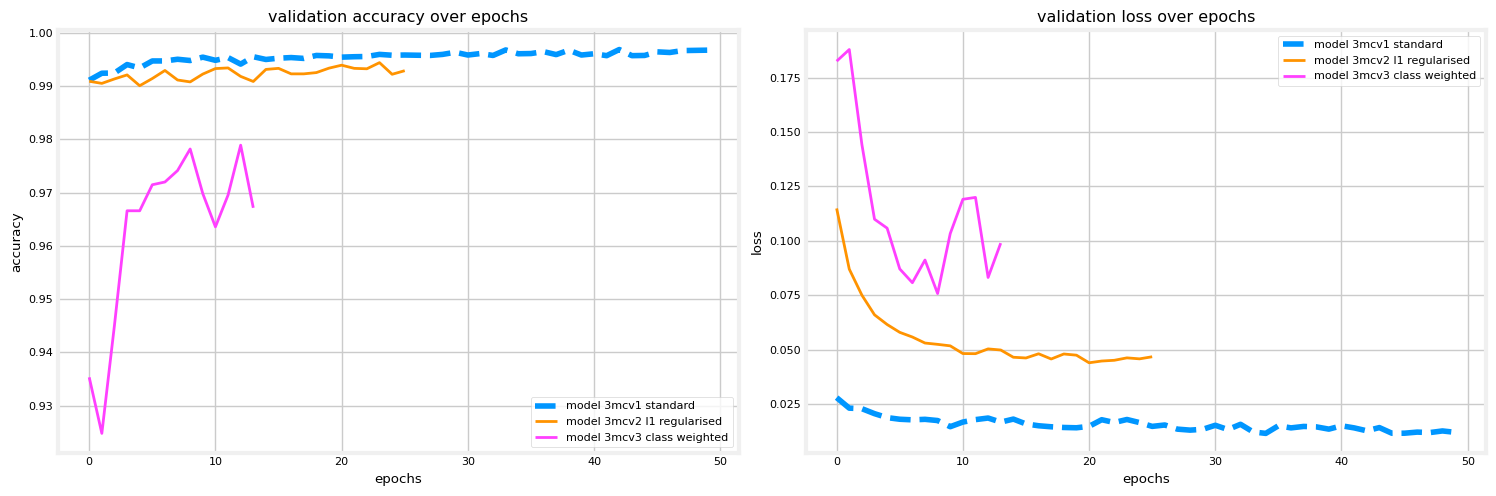

Final multiclass results:
          Metric Model 3mcv1 standard Model 3mcv2 l1 regularised  \
0  Test accuracy               78.05%                     74.03%   
1       Macro f1                 0.60                       0.54   
2   Macro recall                 0.58                       0.52   

  Model 3mcv3 class weighted  
0                     79.21%  
1                       0.58  
2                       0.68  


In [10]:
# plots and results table for multiclass nn models 3mcv1 3mcv2 3mcv3


# predictions and reports
y_pred_3MCv1_probs = model_3MCv1.predict(X_test)
y_pred_3MCv1 = np.argmax(y_pred_3MCv1_probs, axis=1)
test_loss_3MCv1, test_acc_3MCv1 = model_3MCv1.evaluate(X_test, y_test, verbose=2)
report_3MCv1 = classification_report(y_test, y_pred_3MCv1, output_dict=True, zero_division=0)

y_pred_3MCv2_probs = model_3MCv2.predict(X_test)
y_pred_3MCv2 = np.argmax(y_pred_3MCv2_probs, axis=1)
test_loss_3MCv2, test_acc_3MCv2 = model_3MCv2.evaluate(X_test, y_test, verbose=2)
report_3MCv2 = classification_report(y_test, y_pred_3MCv2, output_dict=True, zero_division=0)

y_pred_3MCv3_probs = model_3MCv3.predict(X_test)
y_pred_3MCv3 = np.argmax(y_pred_3MCv3_probs, axis=1)
test_loss_3MCv3, test_acc_3MCv3 = model_3MCv3.evaluate(X_test, y_test, verbose=2)
report_3MCv3 = classification_report(y_test, y_pred_3MCv3, output_dict=True, zero_division=0)

# extract macro metrics
macro_f1_3MCv1 = report_3MCv1["macro avg"]["f1-score"]
macro_rec_3MCv1 = report_3MCv1["macro avg"]["recall"]

macro_f1_3MCv2 = report_3MCv2["macro avg"]["f1-score"]
macro_rec_3MCv2 = report_3MCv2["macro avg"]["recall"]

macro_f1_3MCv3 = report_3MCv3["macro avg"]["f1-score"]
macro_rec_3MCv3 = report_3MCv3["macro avg"]["recall"]

# plots
plt.close("all")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_3MCv1.history["val_accuracy"], label="model 3mcv1 standard", linestyle="--")
ax1.plot(history_3MCv2.history["val_accuracy"], label="model 3mcv2 l1 regularised", linewidth=2)
ax1.plot(history_3MCv3.history["val_accuracy"], label="model 3mcv3 class weighted", linewidth=2)
ax1.set_title("validation accuracy over epochs")
ax1.set_xlabel("epochs")
ax1.set_ylabel("accuracy")
ax1.legend()
ax1.grid(True)

ax2.plot(history_3MCv1.history["val_loss"], label="model 3mcv1 standard", linestyle="--")
ax2.plot(history_3MCv2.history["val_loss"], label="model 3mcv2 l1 regularised", linewidth=2)
ax2.plot(history_3MCv3.history["val_loss"], label="model 3mcv3 class weighted", linewidth=2)
ax2.set_title("validation loss over epochs")
ax2.set_xlabel("epochs")
ax2.set_ylabel("loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# results table
results_df = pd.DataFrame({
    "Metric": ["Test accuracy", "Macro f1", "Macro recall"],
    "Model 3mcv1 standard": [
        f"{test_acc_3MCv1*100:.2f}%",
        f"{macro_f1_3MCv1:.2f}",
        f"{macro_rec_3MCv1:.2f}"
    ],
    "Model 3mcv2 l1 regularised": [
        f"{test_acc_3MCv2*100:.2f}%",
        f"{macro_f1_3MCv2:.2f}",
        f"{macro_rec_3MCv2:.2f}"
    ],
    "Model 3mcv3 class weighted": [
        f"{test_acc_3MCv3*100:.2f}%",
        f"{macro_f1_3MCv3:.2f}",
        f"{macro_rec_3MCv3:.2f}"
    ]
})

print("Final multiclass results:")
print(results_df)



## 5 - Binary classification

### 5.1 - Model 3BINv1: Binary neural network
This model applies a feed-forward neural network to the binary intrusion detection task, distinguishing normal traffic from intrusive activity. The setup is similar to the multi-class baseline, using two fully connected hidden layers with ReLU activations and dropout regularisation, followed by a sigmoid output layer. The model is trained using binary cross-entropy and accuracy as the primary optimisation metric, with class labels encoded as binary targets (normal vs attack). This binary formulation serves as a baseline neural network for comparison with both multi-class models and the classical binary classifiers.

In [11]:
print("Building model 3binv1")
model_bin_3BINv1 = Sequential([
    Dense(128, activation='relu', input_shape=input_shape),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_bin_3BINv1.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

print("Starting training")
history_bin_3BINv1 = model_bin_3BINv1.fit(
    X_train, y_train_bin,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_bin),
    verbose=1
)

Building model 3binv1
Starting training
Epoch 1/50


/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9791 - loss: 0.0596 - val_accuracy: 0.9913 - val_loss: 0.0290
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9911 - loss: 0.0273 - val_accuracy: 0.9927 - val_loss: 0.0207
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9924 - loss: 0.0231 - val_accuracy: 0.9946 - val_loss: 0.0175
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9930 - loss: 0.0206 - val_accuracy: 0.9940 - val_loss: 0.0167
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9934 - loss: 0.0185 - val_accuracy: 0.9945 - val_loss: 0.0159
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9942 - loss: 0.0176 - val_accuracy: 0.9940 - val_loss: 0.0156
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9943 - loss: 0.0160 - val_accuracy: 0.9942 - val_loss: 0.0143
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9944 - loss: 0.0158 - val_accurac

In [12]:
# prediction and accuracy model 3binv1
test_loss_3BINv1, test_acc_3BINv1 = model_bin_3BINv1.evaluate(X_test, y_test_bin, verbose=2)
print(f"Test accuracy: {test_acc_3BINv1*100:.2f}%")

y_pred_3BINv1_probs = model_bin_3BINv1.predict(X_test).ravel()
y_pred_3BINv1 = (y_pred_3BINv1_probs >= 0.5).astype("int32")

print("Classification report 3binv1")
print(classification_report(
    y_test_bin,
    y_pred_3BINv1,
    target_names=["Normal", "Attack"],
    zero_division=0
))


705/705 - 1s - 2ms/step - accuracy: 0.7875 - loss: 3.9399
Test accuracy: 78.75%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 853us/step
Classification report 3binv1
              precision    recall  f1-score   support

      Normal       0.69      0.93      0.79      9711
      Attack       0.93      0.68      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.81      0.81      0.79     22544
weighted avg       0.83      0.79      0.79     22544



### 5.2 Training model 3BINv2: Neural network with L1 regularisation and early stopping mechanism
This model follows the same approach as the multi-class regularised neural network (Model 3MCv2), applying L1 regularisation and early stopping to the binary intrusion detection task.

In [13]:
print("Building model 3binv2 l1 regularised")

reg = tf.keras.regularizers.l1(1e-4)

model_bin_3BINv2 = Sequential([
    Dense(128, activation="relu", input_shape=input_shape, kernel_regularizer=reg),
    Dropout(0.3),
    Dense(64, activation="relu", kernel_regularizer=reg),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_bin_3BINv2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping_bin = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True
)

print("Starting training")

history_bin_3BINv2 = model_bin_3BINv2.fit(
    X_train, y_train_bin,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_bin),
    callbacks=[early_stopping_bin],
    verbose=1
)


Building model 3binv2 l1 regularised
Starting training
Epoch 1/50


/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9791 - loss: 0.1442 - val_accuracy: 0.9899 - val_loss: 0.0833
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9888 - loss: 0.0752 - val_accuracy: 0.9893 - val_loss: 0.0610
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9893 - loss: 0.0615 - val_accuracy: 0.9909 - val_loss: 0.0532
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9906 - loss: 0.0544 - val_accuracy: 0.9923 - val_loss: 0.0481
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9910 - loss: 0.0504 - val_accuracy: 0.9916 - val_loss: 0.0486
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9914 - loss: 0.0475 - val_accuracy: 0.9929 - val_loss: 0.0415
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9915 - loss: 0.0465 - val_accuracy: 0.9930 - val_loss: 0.0430
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9916 - loss: 0.0454 - val_accurac

In [14]:
# prediction and accuracy model 3binv2
test_loss_3BINv2, test_acc_3BINv2 = model_bin_3BINv2.evaluate(X_test, y_test_bin, verbose=2)
print(f"Test accuracy: {test_acc_3BINv2*100:.2f}%")

y_pred_3BINv2_probs = model_bin_3BINv2.predict(X_test).ravel()
y_pred_3BINv2 = (y_pred_3BINv2_probs >= 0.5).astype("int32")

print("Classification report 3binv2")
print(classification_report(
    y_test_bin,
    y_pred_3BINv2,
    target_names=["Normal", "Attack"],
    zero_division=0
))


705/705 - 1s - 2ms/step - accuracy: 0.7775 - loss: 1.4023
Test accuracy: 77.75%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification report 3binv2
              precision    recall  f1-score   support

      Normal       0.67      0.97      0.79      9711
      Attack       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.77     22544



705/705 - 1s - 972us/step - accuracy: 0.7875 - loss: 3.9399
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 857us/step
705/705 - 1s - 1ms/step - accuracy: 0.7775 - loss: 1.4023
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 780us/step
Classification report 3binv1
              precision    recall  f1-score   support

      Normal       0.69      0.93      0.79      9711
      Attack       0.93      0.68      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.81      0.81      0.79     22544
weighted avg       0.83      0.79      0.79     22544

Classification report 3binv2
              precision    recall  f1-score   support

      Normal       0.67      0.97      0.79      9711
      Attack       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.77     22544



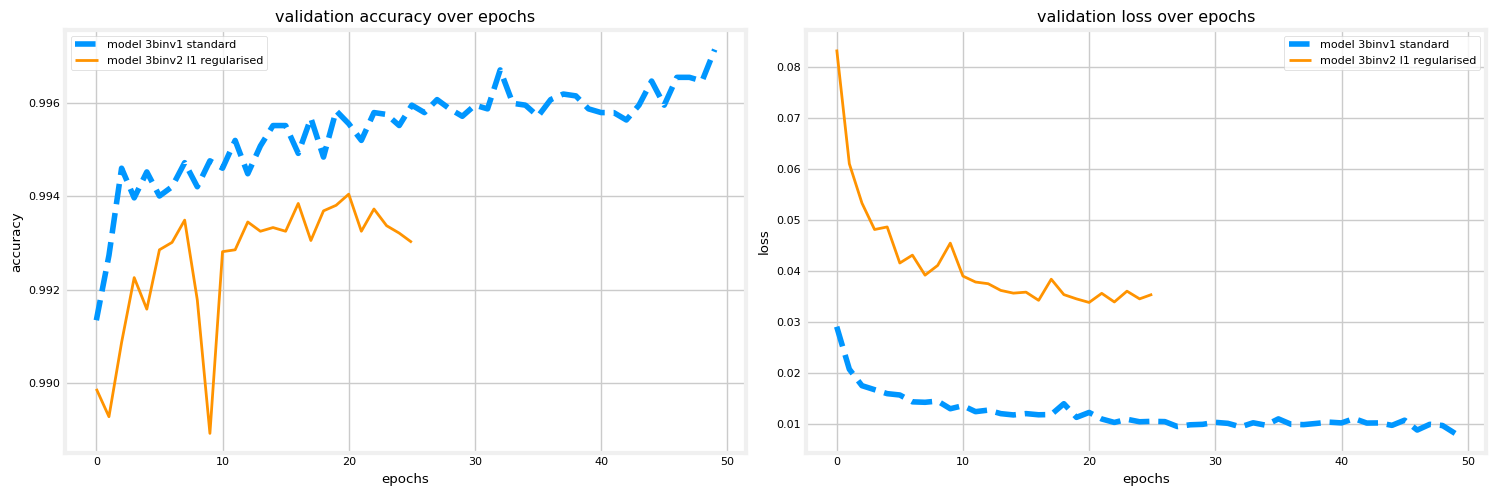

Final binary results
          Metric Model 3binv1 standard Model 3binv2 l1 regularised
0  Test accuracy                78.75%                      77.75%
1       Macro f1                  0.79                        0.78
2   Macro recall                  0.81                        0.80


In [15]:
# Accuracy and loss comparison of both multi-classclassification models over epochs
# evaluate and generate predictions for 3binv1
test_loss_3BINv1, test_acc_3BINv1 = model_bin_3BINv1.evaluate(X_test, y_test_bin, verbose=2)
y_pred_3BINv1_probs = model_bin_3BINv1.predict(X_test).ravel()
y_pred_3BINv1 = (y_pred_3BINv1_probs >= 0.5).astype("int32")
report_3BINv1 = classification_report(
    y_test_bin,
    y_pred_3BINv1,
    output_dict=True,
    target_names=["Normal", "Attack"],
    zero_division=0
)

# evaluate and generate predictions for 3binv2
test_loss_3BINv2, test_acc_3BINv2 = model_bin_3BINv2.evaluate(X_test, y_test_bin, verbose=2)
y_pred_3BINv2_probs = model_bin_3BINv2.predict(X_test).ravel()
y_pred_3BINv2 = (y_pred_3BINv2_probs >= 0.5).astype("int32")
report_3BINv2 = classification_report(
    y_test_bin,
    y_pred_3BINv2,
    output_dict=True,
    target_names=["Normal", "Attack"],
    zero_division=0
)

# print the classification reports (same as multiclass)
print("Classification report 3binv1")
print(classification_report(
    y_test_bin,
    y_pred_3BINv1,
    target_names=["Normal", "Attack"],
    zero_division=0
))

print("Classification report 3binv2")
print(classification_report(
    y_test_bin,
    y_pred_3BINv2,
    target_names=["Normal", "Attack"],
    zero_division=0
))

# plots
plt.close("all")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_bin_3BINv1.history["val_accuracy"], label="model 3binv1 standard", linestyle="--")
ax1.plot(history_bin_3BINv2.history["val_accuracy"], label="model 3binv2 l1 regularised", linewidth=2)
ax1.set_title("validation accuracy over epochs")
ax1.set_xlabel("epochs")
ax1.set_ylabel("accuracy")
ax1.legend()
ax1.grid(True)

ax2.plot(history_bin_3BINv1.history["val_loss"], label="model 3binv1 standard", linestyle="--")
ax2.plot(history_bin_3BINv2.history["val_loss"], label="model 3binv2 l1 regularised", linewidth=2)
ax2.set_title("validation loss over epochs")
ax2.set_xlabel("epochs")
ax2.set_ylabel("loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# results table with test accuracy, macro f1, macro recall (mirrors multiclass summary)
results_df = pd.DataFrame({
    "Metric": ["Test accuracy", "Macro f1", "Macro recall"],
    "Model 3binv1 standard": [
        f"{test_acc_3BINv1*100:.2f}%",
        f"{report_3BINv1['macro avg']['f1-score']:.2f}",
        f"{report_3BINv1['macro avg']['recall']:.2f}"
    ],
    "Model 3binv2 l1 regularised": [
        f"{test_acc_3BINv2*100:.2f}%",
        f"{report_3BINv2['macro avg']['f1-score']:.2f}",
        f"{report_3BINv2['macro avg']['recall']:.2f}"
    ]
})

print("Final binary results")
print(results_df)



## 6 - Visualisation
To complement the quantitative evaluation, additional visualisations are added to illustrate class-specific error patterns and threshold-dependent trade-offs. These analyses provide insight into why changes in model configuration lead to limited improvements, particularly for minority attack classes.

### 6.1 Visualisation multi-classification

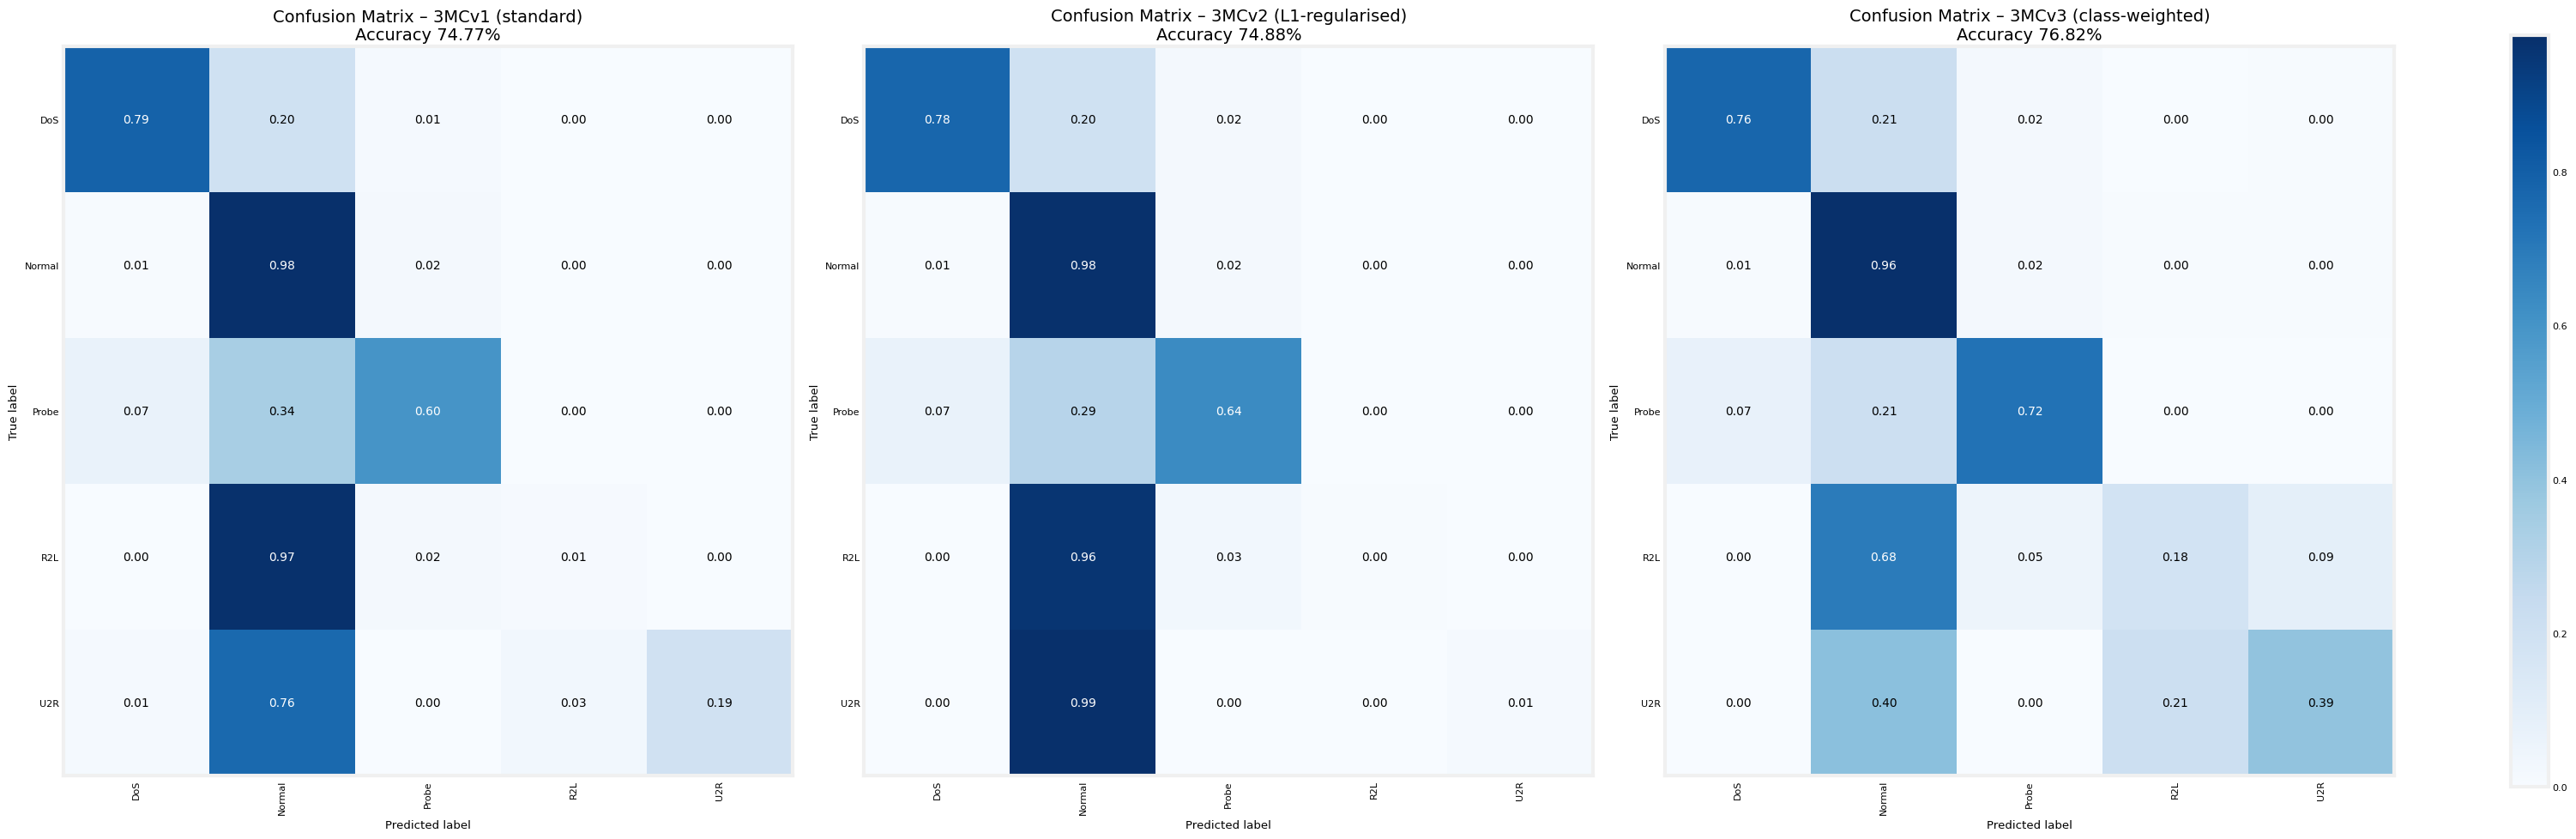

In [22]:

label_map = {
    "normal": "Normal",
    "dos": "DoS",
    "probe": "Probe",
    "r2l": "R2L",
    "u2r": "U2R",
}

# Load encoder and map to display names
y_encoder = joblib.load("data/processed/label_encoder.joblib")
class_names = [label_map[c] for c in y_encoder.classes_]
class_ids = np.arange(len(class_names))

def plot_cm(ax, y_true, y_pred, title, class_ids, class_names, normalize=True):
    cm = confusion_matrix(
        y_true, y_pred,
        labels=class_ids,
        normalize="true" if normalize else None
    )

    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title, fontsize=14)

    ax.set_xticks(class_ids)
    ax.set_yticks(class_ids)
    ax.set_xticklabels(class_names, rotation=90)
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f"{cm[i, j]:.2f}" if normalize else f"{int(cm[i, j])}",
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=10
            )

    return im

plt.close("all")
fig, axes = plt.subplots(1, 3, figsize=(30, 10), constrained_layout=True)

im = plot_cm(
    axes[0], y_test, y_pred_3MCv1,
    f"Confusion Matrix – 3MCv1 (standard)\nAccuracy {test_acc_3MCv1:.2%}",
    class_ids, class_names, normalize=True
)

plot_cm(
    axes[1], y_test, y_pred_3MCv2,
    f"Confusion Matrix – 3MCv2 (L1-regularised)\nAccuracy {test_acc_3MCv2:.2%}",
    class_ids, class_names, normalize=True
)

plot_cm(
    axes[2], y_test, y_pred_3MCv3,
    f"Confusion Matrix – 3MCv3 (class-weighted)\nAccuracy {test_acc_3MCv3:.2%}",
    class_ids, class_names, normalize=True
)

fig.colorbar(im, ax=axes, shrink=0.9)

plt.show()



### 6.2 Visualisation and optimalisation binary classification

Visualising model 3binv1 standard
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 761us/step


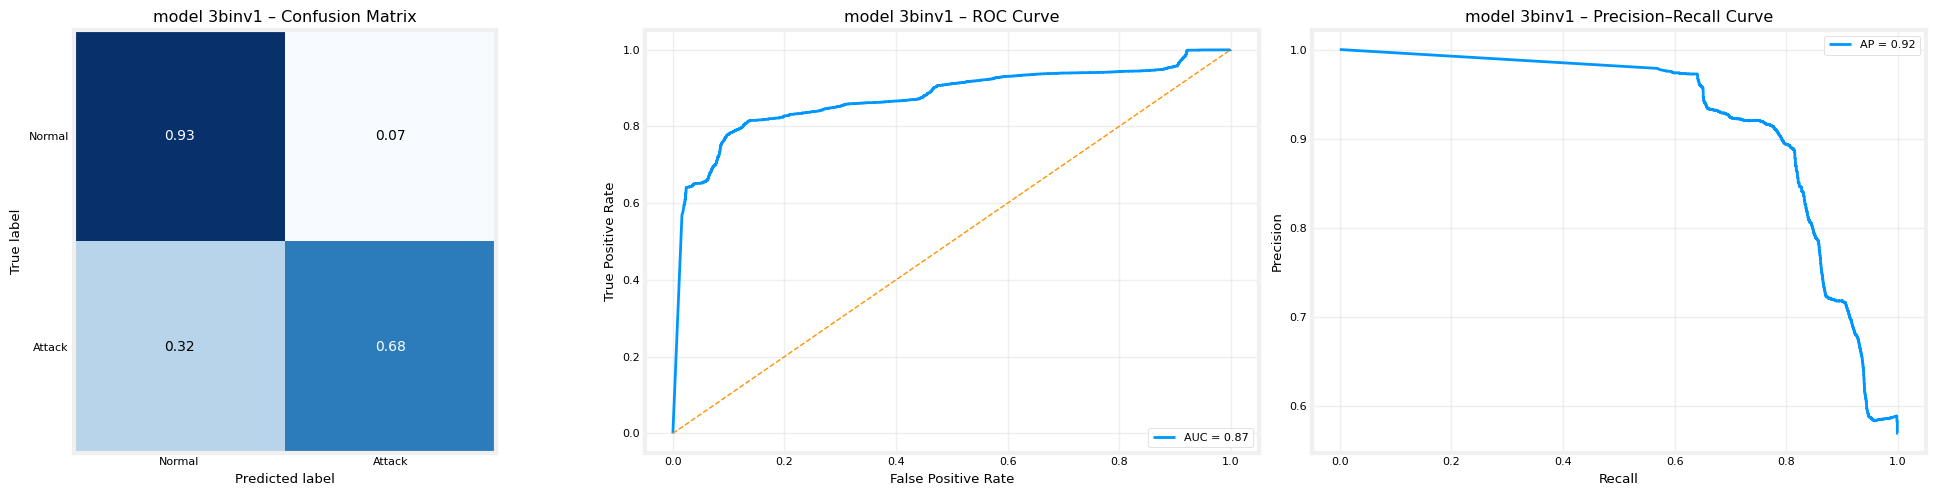

Visualising model 3binv2 l1 regularised
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step


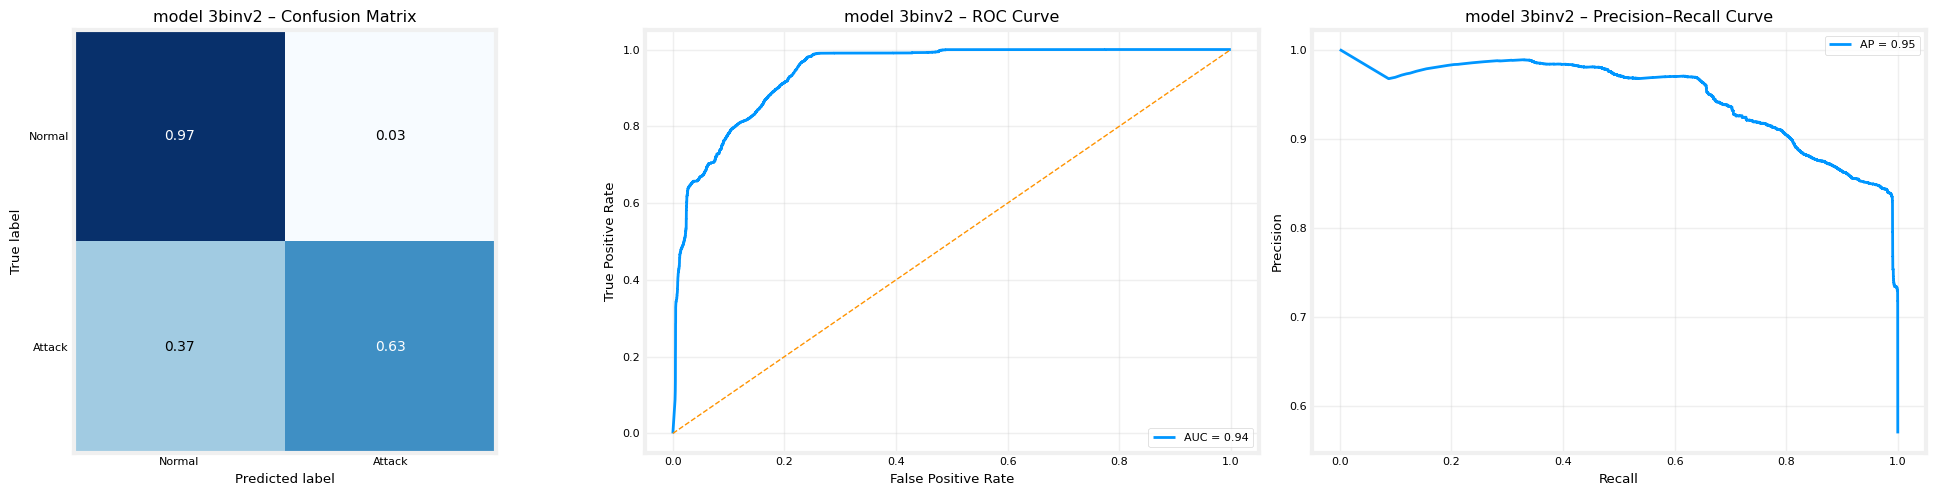

In [17]:
def plot_performance_visuals(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test).ravel()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # CM
    cm = confusion_matrix(
        y_test, y_pred,
        labels=[0, 1],
        normalize="true"
    )

    im = axes[0].imshow(cm, interpolation="nearest", cmap="Blues")
    axes[0].set_title(f"{model_name} – Confusion Matrix")

    axes[0].set_xticks([0, 1])
    axes[0].set_yticks([0, 1])
    axes[0].set_xticklabels(["Normal", "Attack"])
    axes[0].set_yticklabels(["Normal", "Attack"])

    axes[0].set_xlabel("Predicted label")
    axes[0].set_ylabel("True label")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0].text(
                j, i, f"{cm[i, j]:.2f}",
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=10
            )

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.2f}")
    axes[1].plot([0, 1], [0, 1], lw=1, linestyle="--")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"{model_name} – ROC Curve")
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)

    # PRECISION–RECALL
    precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
    ap = average_precision_score(y_test, y_pred_prob)
    axes[2].plot(recall, precision, lw=2, label=f"AP = {ap:.2f}")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].set_title(f"{model_name} – Precision–Recall Curve")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Visualising model 3binv1 standard")
plot_performance_visuals(model_bin_3BINv1, X_test, y_test_bin, "model 3binv1")

print("Visualising model 3binv2 l1 regularised")
plot_performance_visuals(model_bin_3BINv2, X_test, y_test_bin, "model 3binv2")

The previous results highlight an important practical consideration: neural networks produce probability scores that must be converted into binary decisions using a threshold. The default threshold of 0.5 is arbitrary and does not necessarily correspond to the optimal operating point for intrusion detection. Adjusting the decision threshold based on validation performance can meaningfully shift the balance between missed attacks and false alarms without altering the underlying model. Nevertheless, even with threshold tuning, the observed improvements remain incremental, reinforcing the conclusion that binary neural networks provide only modest advantages over simpler or tree-based models in this setting.

In [ ]:
def find_optimal_threshold(model, X_val, y_val, model_name):
    y_val_prob = model.predict(X_val).ravel()
    thresholds = np.arange(0.0, 1.0, 0.01)
    f1_scores = [f1_score(y_val, (y_val_prob >= t).astype(int)) for t in thresholds]

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"{model_name} validation threshold optimisation")
    print(f"optimal threshold {best_threshold:.2f} best f1 {best_f1:.2f}")

    return best_threshold

thresh_v1 = find_optimal_threshold(model_bin_3BINv1, X_val, y_val_bin, "model 3binv1")
thresh_v2 = find_optimal_threshold(model_bin_3BINv2, X_val, y_val_bin, "model 3binv2")

y_pred_opt_v1 = (model_bin_3BINv1.predict(X_test).ravel() >= thresh_v1).astype(int)
y_pred_opt_v2 = (model_bin_3BINv2.predict(X_test).ravel() >= thresh_v2).astype(int)

print("Final report model 3binv1 threshold tuned")
print(f"accuracy {accuracy_score(y_test_bin, y_pred_opt_v1)*100:.2f}%")
print(classification_report(y_test_bin, y_pred_opt_v1, target_names=["Normal", "Attack"], zero_division=0))

print("Final report model 3binv2 threshold tuned")
print(f"accuracy {accuracy_score(y_test_bin, y_pred_opt_v2)*100:.2f}%")
print(classification_report(y_test_bin, y_pred_opt_v2, target_names=["Normal", "Attack"], zero_division=0))


788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
model 3binv1 validation threshold optimisation
optimal threshold 0.47 best f1 1.00
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
model 3binv2 validation threshold optimisation
optimal threshold 0.61 best f1 0.99
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Final report model 3binv1 threshold tuned
accuracy 78.31%
              precision    recall  f1-score   support

      Normal       0.67      0.98      0.80      9711
      Attack       0.97      0.64      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.81      0.78     22544
weighted avg       0.84      0.78      0.78     22544

Final report model 3binv2 threshold tuned
accuracy 77.86%
              precision    recall  f1-score   support

      Normal       0.67      0.98      0.79      9711
      Attack       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro 

To summarise the binary analysis, ROC and precision–recall curves are shown alongside confusion matrices evaluated at the optimised thresholds, illustrating both ranking performance and the resulting classification trade-offs.

705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 910us/step


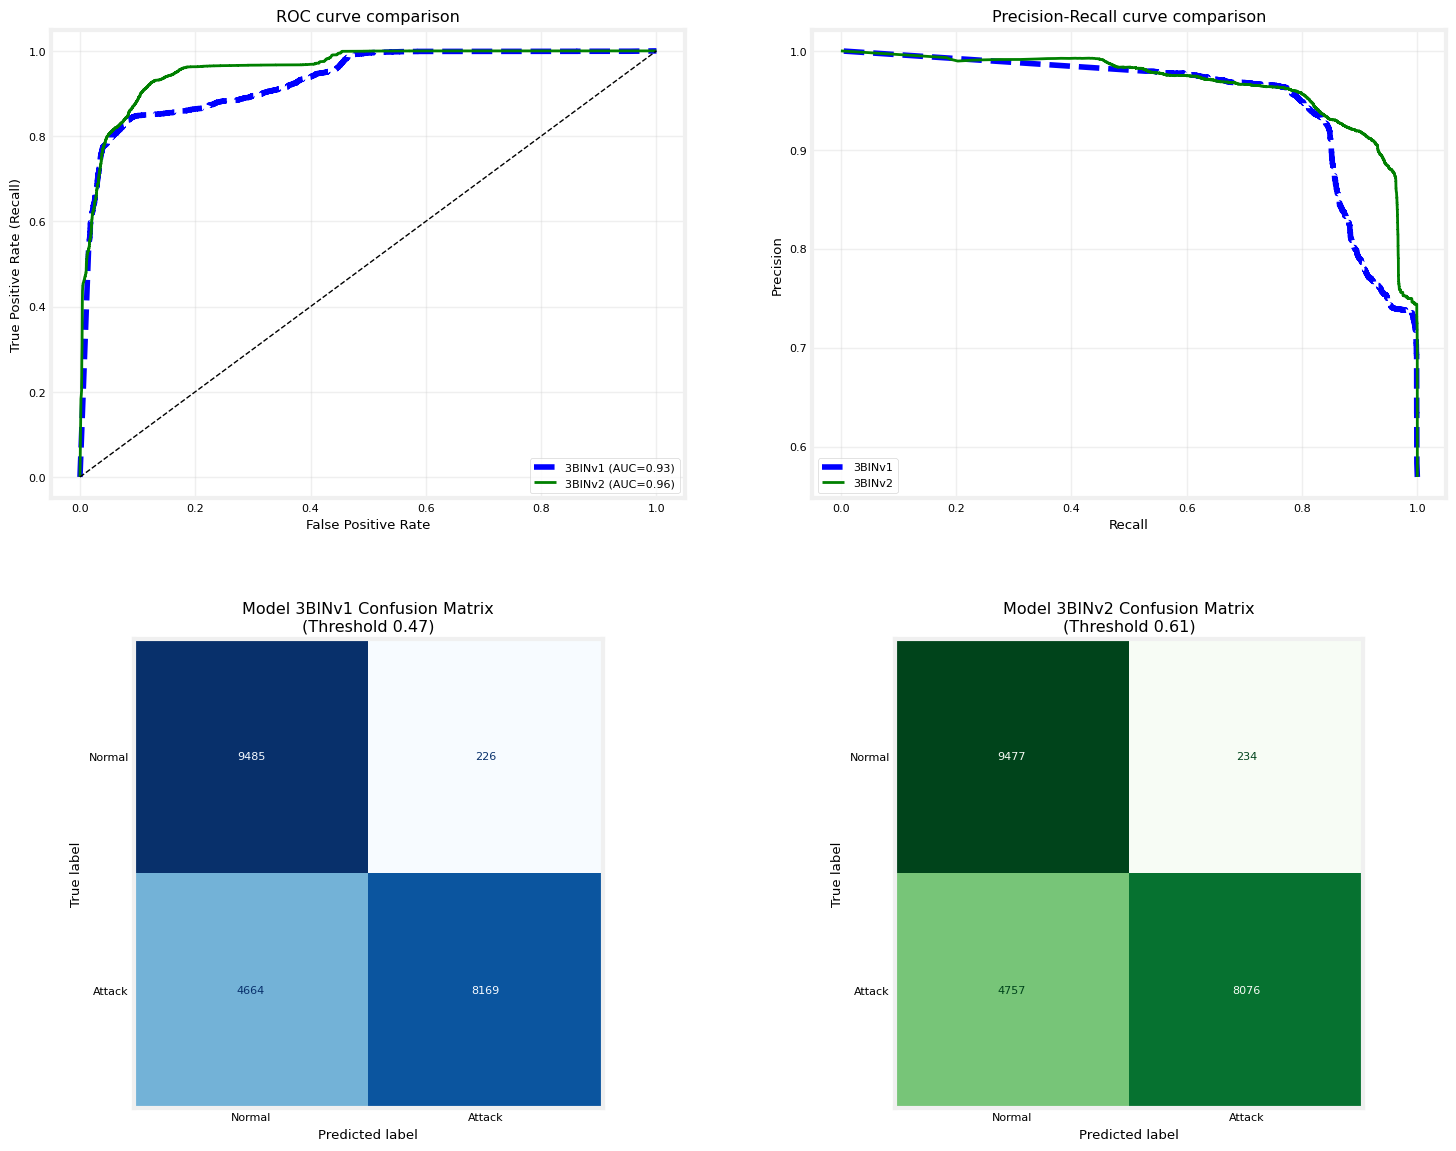

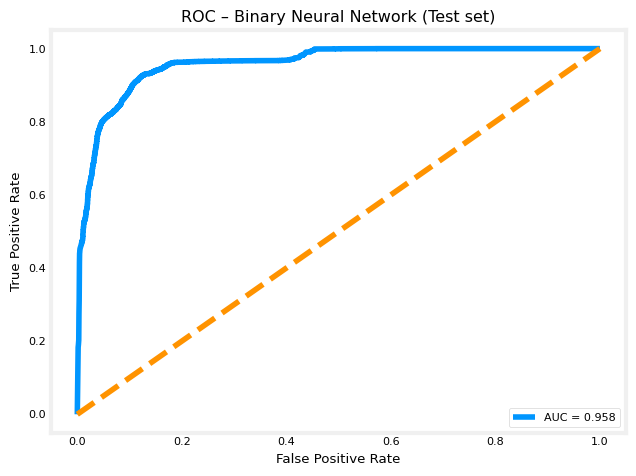

In [32]:
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve

y_prob_v1 = model_bin_3BINv1.predict(X_test).ravel()
y_prob_v2 = model_bin_3BINv2.predict(X_test).ravel()

# t1 = locals().get('thresh_v1', 0.01)
# t2 = locals().get('thresh_v2', 0.01)
t1 = thresh_v1 if "thresh_v1" in globals() else 0.5
t2 = thresh_v2 if "thresh_v2" in globals() else 0.5


fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plt.subplots_adjust(hspace=0.3)

# Top Left: ROC Comparison
fpr1, tpr1, _ = roc_curve(y_test_bin, y_prob_v1)
fpr2, tpr2, _ = roc_curve(y_test_bin, y_prob_v2)
# axes[0, 0].plot(fpr1, tpr1, linestyle='--', color='blue', label=f'3BINv1 (AUC={auc(fpr1, tpr1):.2f})')
# axes[0, 0].plot(fpr2, tpr2, linewidth=2, color='green', label=f'3BINv2 (AUC={auc(fpr2, tpr2):.2f})')
auc1 = roc_auc_score(y_test_bin, y_prob_v1)
auc2 = roc_auc_score(y_test_bin, y_prob_v2)

axes[0, 0].plot(fpr1, tpr1, linestyle='--', color='blue',  label=f'3BINv1 (AUC={auc1:.2f})')
axes[0, 0].plot(fpr2, tpr2, linewidth=2,   color='green', label=f'3BINv2 (AUC={auc2:.2f})')

axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 0].set_title('ROC curve comparison')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate (Recall)')
axes[0, 0].legend(loc="lower right")
axes[0, 0].grid(alpha=0.3)

# Top Right: Precision-Recall Comparison
p1, r1, _ = precision_recall_curve(y_test_bin, y_prob_v1)
p2, r2, _ = precision_recall_curve(y_test_bin, y_prob_v2)
axes[0, 1].plot(r1, p1, linestyle='--', color='blue', label='3BINv1')
axes[0, 1].plot(r2, p2, linewidth=2, color='green', label='3BINv2')
axes[0, 1].set_title('Precision-Recall curve comparison')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].legend(loc="lower left")
axes[0, 1].grid(alpha=0.3)

# Bottom Left: Confusion Matrix 3BINv1
cm_v1 = confusion_matrix(y_test_bin, (y_prob_v1 >= t1).astype(int))
disp_v1 = ConfusionMatrixDisplay(confusion_matrix=cm_v1, display_labels=['Normal', 'Attack'])
disp_v1.plot(cmap='Blues', ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title(f'Model 3BINv1 Confusion Matrix\n(Threshold {t1:.2f})')

# Bottom Right: Confusion Matrix 3BINv2
cm_v2 = confusion_matrix(y_test_bin, (y_prob_v2 >= t2).astype(int))
disp_v2 = ConfusionMatrixDisplay(confusion_matrix=cm_v2, display_labels=['Normal', 'Attack'])
disp_v2.plot(cmap='Greens', ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title(f'Model 3BINv2 Confusion Matrix\n(Threshold {t2:.2f})')

plt.show()

# poster ROC
fpr, tpr, _ = roc_curve(y_test_bin, y_prob_v2)
roc_auc = roc_auc_score(y_test_bin, y_prob_v2)

plt.figure(figsize=(6.4, 4.8))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], "--")
plt.title("ROC – Binary Neural Network (Test set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend([f"AUC = {roc_auc:.3f}"], loc="lower right")
plt.tight_layout()
plt.show()